In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

%matplotlib inline

In [2]:
import warnings 
from scipy.stats import mode
#avoid the warning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

# Data read

## 📊 Dataset

This project uses a publicly available dataset:

- **Name**: Dog Adaptability  
- **License**: Apache License 2.0  
- **Source**: https://www.kaggle.com/datasets/agarwalyashhh/dog-adaptability/data?select=training_data.csv  

> **Note:** This project does **not** redistribute the dataset directly. Only the reference link and license information are provided, in accordance with the dataset's terms of use.

In [3]:
data_df = pd.read_csv("dog_adaptability.csv")
data_df.head()

,id,adaptability,good_for_novice_owners,sensitivity_level,tolerates_being_alone,tolerates_cold_weather,tolerates_hot_weather,all_around_friendliness,affectionate_with_family,incredibly_kifriendly_dogs,...,wanderlust_potential,exercise_needs,energy_level,intensity,potential_for_playfulness,breed_group,height,weight,lifspan,adapts_well_to_apartment_living
0,0,3,2,5.0,1,4,3,5,5,4,...,5,4.0,4,4.0,5,Mixed Breed Dogs,7 to 11 inches,70 to 115 pounds,10 to 15 years,Flexible
1,1,3,4,5.0,3,2,2,4,5,3,...,2,3.0,2,2.0,4,Companion Dogs,"2 feet to 2 feet, 4 inches tall at the shoulder",8 to 18 pounds,12 to 15 years,Moderate
2,2,4,3,5.0,3,4,4,5,5,5,...,3,4.0,5,1.0,4,Companion Dogs,23 to 27 inches tall at the shoulder,9 to 15 pounds,8 to 10 years,Versatile
3,3,3,2,3.0,3,4,4,4,5,5,...,4,4.0,5,4.0,4,Mixed Breed Dogs,10 to 13 inches,25 to 27 pounds,8 to 10 years,Resistant
4,4,3,3,2.0,3,3,2,3,4,3,...,3,3.0,3,3.0,3,Mixed Breed Dogs,21 to 25 inches at the shoulder,15 to 35 pounds,10 to 11 years,Versatile


# Preprocessing

In [4]:
data_df = data_df.drop(['id'], axis=1)
numerical_columns = data_df.select_dtypes(include=['number']).columns.to_list()
selected_data = data_df[numerical_columns]
knn_imputer = KNNImputer(n_neighbors=5)
imputed_data = knn_imputer.fit_transform(selected_data)
data = pd.DataFrame(imputed_data,columns=numerical_columns)
data.head()

,adaptability,good_for_novice_owners,sensitivity_level,tolerates_being_alone,tolerates_cold_weather,tolerates_hot_weather,all_around_friendliness,affectionate_with_family,incredibly_kifriendly_dogs,dog_friendly,...,easy_to_train,intelligence,potential_for_mouthiness,prey_drive,tendency_to_bark_or_howl,wanderlust_potential,exercise_needs,energy_level,intensity,potential_for_playfulness
0,3.0,2.0,5.0,1.0,4.0,3.0,5.0,5.0,4.0,5.0,...,4.0,4.0,4.0,5.0,4.0,5.0,4.0,4.0,4.0,5.0
1,3.0,4.0,5.0,3.0,2.0,2.0,4.0,5.0,3.0,3.0,...,3.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,4.0
2,4.0,3.0,5.0,3.0,4.0,4.0,5.0,5.0,5.0,4.0,...,3.0,4.0,2.0,5.0,1.0,3.0,4.0,5.0,1.0,4.0
3,3.0,2.0,3.0,3.0,4.0,4.0,4.0,5.0,5.0,1.0,...,5.0,4.0,2.0,4.0,1.0,4.0,4.0,5.0,4.0,4.0
4,3.0,3.0,2.0,3.0,3.0,2.0,3.0,4.0,3.0,2.0,...,3.0,3.0,3.0,5.0,5.0,3.0,3.0,3.0,3.0,3.0


In [5]:
data['breed_group'] = data_df['breed_group']
data['height'] = data_df['height']
data['weight'] = data_df['weight']
data['lifspan'] = data_df['lifspan']
data['adapts_well_to_apartment_living'] = data_df['adapts_well_to_apartment_living']

In [6]:
data.lifspan = data.lifspan.str.lower()
data['lifspan'].replace('12 to 18 years. tiny bernedoodles tend to live longer than standard.', '12 to 18 years', inplace=True) 
data['lifspan'].replace('12 - 15 years', '12 to 15 years', inplace=True) 
data['lifspan'].replace('10 to 13', '10 to 13 years', inplace=True)
data['lifspan'].replace('13 to 17+ years', '13 to 17 years', inplace=True)
data.lifspan = data.lifspan.str.strip('old. ')

In [7]:
data['weight'].replace('35 - 60 pounds', '35 to 60 pounds', inplace=True)
data.weight = data.weight.str.strip('.From ')
data['weight'] = data['weight'].fillna(data['weight'].mode().iloc[0])

In [8]:
height_mapping = {name: idx for idx, name in enumerate(data['height'].unique())}
weight_mapping = {name: idx for idx, name in enumerate(data['weight'].unique())}
lifspan_mapping = {name: idx for idx, name in enumerate(data['lifspan'].unique())}

data['breed_group'] = data['breed_group'].map({'Mixed Breed Dogs':0, 'Companion Dogs':1, 'Working Dogs':2, 'Terrier Dogs':3, 
                                               'Sporting Dogs':4, 'Hound Dogs':5, 'Hybrid Dogs':6, 'Herding Dogs':7})
data['height'] = data['height'].map(height_mapping)
data['weight'] = data['weight'].map(weight_mapping)
data['lifspan'] = data['lifspan'].map(lifspan_mapping)
data['adapts_well_to_apartment_living'] = data['adapts_well_to_apartment_living'].map({'Flexible':0,'Moderate':0, 'Versatile':0,
                                                                                       'Resistant':1, 'Hesitant':1})

In [9]:
target = data['adapts_well_to_apartment_living']

X = data.drop(['adapts_well_to_apartment_living'], axis=1)
y = target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [10]:
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

selector = SelectFromModel(model, threshold= 0.02, prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

selected_features_indices = selector.get_support(indices=True)
selected_features = data.columns[selected_features_indices]
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_features)

In [11]:
X_train_selected_df

,adaptability,good_for_novice_owners,sensitivity_level,tolerates_hot_weather,all_around_friendliness,affectionate_with_family,incredibly_kifriendly_dogs,dog_friendly,friendly_towarstrangers,health_grooming,...,easy_to_train,intelligence,potential_for_mouthiness,prey_drive,wanderlust_potential,exercise_needs,energy_level,intensity,breed_group,height
0,4.0,1.0,3.0,3.0,4.0,5.0,5.0,4.0,5.0,4.0,...,5.0,5.0,5.0,4.0,4.0,4.0,4.0,5.0,2.0,60.0
1,3.0,4.0,2.0,4.0,4.0,5.0,1.0,3.0,4.0,2.0,...,3.0,4.0,2.0,3.0,2.0,4.0,3.0,5.0,5.0,15.0
2,3.0,2.0,4.0,3.0,4.0,5.0,5.0,5.0,4.0,3.0,...,2.0,4.0,4.0,2.0,3.0,5.0,5.0,4.0,7.0,38.0
3,2.0,3.0,4.0,2.0,4.0,5.0,4.0,4.0,3.0,4.0,...,5.0,3.0,2.0,1.0,3.0,4.0,4.0,2.0,7.0,40.0
4,3.0,4.0,5.0,3.0,4.0,5.0,4.0,5.0,5.0,3.0,...,1.0,5.0,3.0,4.0,3.0,5.0,3.0,3.0,6.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,4.0,4.0,4.0,3.0,3.0,4.0,4.0,2.0,1.0,3.0,...,3.0,4.0,2.0,5.0,3.0,4.0,4.0,4.0,0.0,28.0
2556,3.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,5.0,3.0,...,5.0,5.0,3.0,5.0,5.0,5.0,5.0,5.0,4.0,72.0
2557,4.0,4.0,5.0,3.0,4.0,5.0,5.0,4.0,4.0,2.0,...,4.0,4.0,4.0,3.0,3.0,4.0,5.0,3.0,1.0,44.0
2558,3.0,3.0,4.0,3.0,5.0,5.0,5.0,5.0,5.0,3.0,...,3.0,5.0,3.0,5.0,3.0,4.0,4.0,4.0,5.0,42.0


RANDOM FOREST

In [13]:
rf = RandomForestClassifier()
param_grid_rf = {
    'n_estimators': [50, 100,200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'], refit='accuracy')
grid_search_rf.fit(X_train_selected_df, y_train)
best_params_rf = grid_search_rf.best_params_
y_pred_rf = grid_search_rf.predict(X_test_selected_df)

In [14]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

results_df_rf = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [accuracy_rf, precision_rf, recall_rf, f1_rf]
})

results_df_rf

,Metric,Value
0,Accuracy,0.726562
1,Precision,0.721089
2,Recall,0.726562
3,F1 Score,0.721540


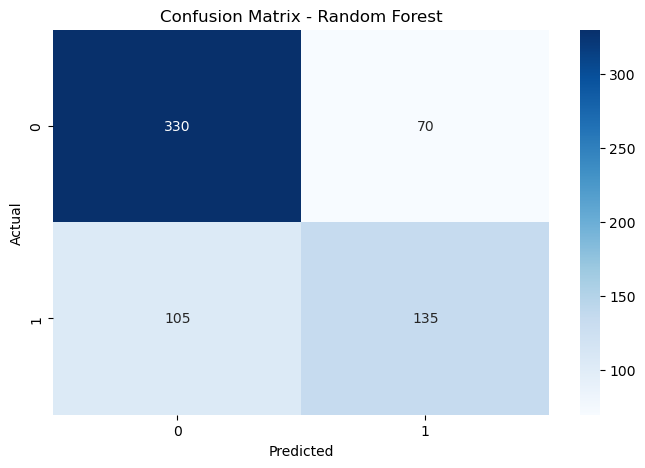

In [16]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

DECISION TREE

In [12]:
dt = DecisionTreeClassifier()
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'], refit='accuracy')
grid_search_dt.fit(X_train_selected_df, y_train)
best_params_dt = grid_search_dt.best_params_
y_pred_dt = grid_search_dt.predict(X_test_selected_df)

In [13]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

results_df_dt = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [accuracy_dt, precision_dt, recall_dt, f1_dt]
})

results_df_dt

,Metric,Value
0,Accuracy,0.660937
1,Precision,0.655999
2,Recall,0.660937
3,F1 Score,0.657883


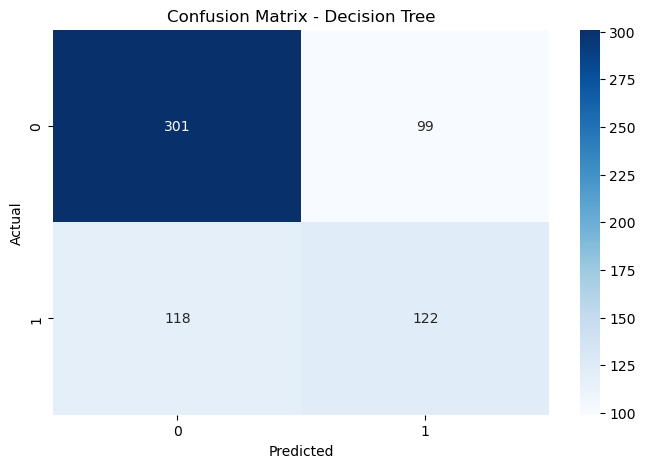

In [14]:
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

GAUSSIAN NAIVE BAYES

In [15]:
gnb = GaussianNB()
param_grid_gnb = {
    'var_smoothing': np.logspace(-9, 0, 10)
}
grid_search_gnb = GridSearchCV(gnb, param_grid_gnb, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'], refit='accuracy')
grid_search_gnb.fit(X_train_selected_df, y_train)
best_params_gnb = grid_search_gnb.best_params_

y_pred_gnb = grid_search_gnb.predict(X_test_selected_df)

In [16]:
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb, average='weighted', zero_division=0)
recall_gnb = recall_score(y_test, y_pred_gnb, average='weighted')
f1_gnb = f1_score(y_test, y_pred_gnb, average='weighted')

results_df_gnb = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [accuracy_gnb, precision_gnb, recall_gnb, f1_gnb]
})

results_df_gnb

,Metric,Value
0,Accuracy,0.704688
1,Precision,0.703049
2,Recall,0.704688
3,F1 Score,0.703783


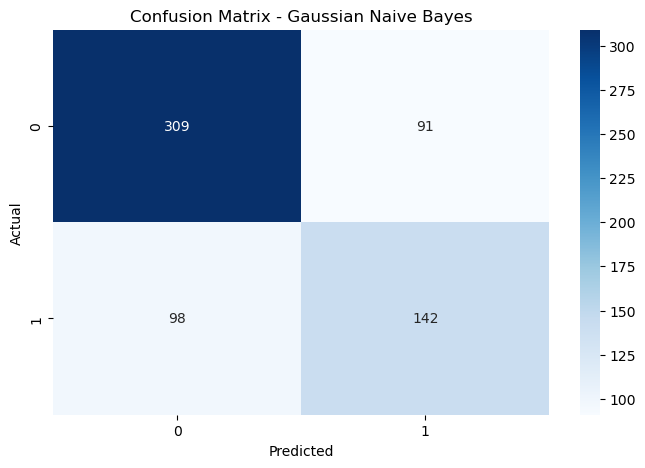

In [17]:
conf_matrix_gnb = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix_gnb, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.show()

KNN

In [18]:
knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'], refit='accuracy')
grid_search_knn.fit(X_train_selected_df, y_train)
best_params_knn = grid_search_knn.best_params_
y_pred_knn = grid_search_knn.predict(X_test_selected_df)

In [19]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

results_df_knn = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [accuracy_knn, precision_knn, recall_knn, f1_knn]
})

results_df_knn

,Metric,Value
0,Accuracy,0.715625
1,Precision,0.712673
2,Recall,0.715625
3,F1 Score,0.713799


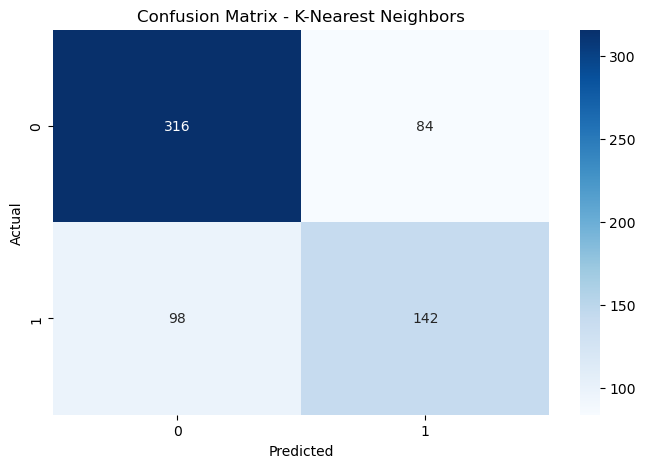

In [20]:
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.show()

SVM

In [26]:
svm = SVC()
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['linear', 'rbf']
}
grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'], refit='accuracy')
grid_search_svm.fit(X_train_selected_df, y_train)
best_params_svm = grid_search_svm.best_params_
y_pred_svm = grid_search_svm.predict(X_test_selected_df)

In [27]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

results_df_svm = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [accuracy_svm, precision_svm, recall_svm, f1_svm]
})

results_df_svm

,Metric,Value
0,Accuracy,0.720313
1,Precision,0.715976
2,Recall,0.720313
3,F1 Score,0.717183


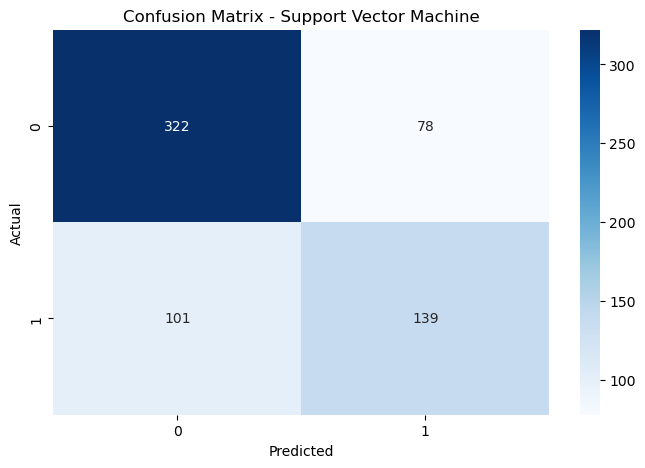

In [28]:
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Support Vector Machine')
plt.show()

Final Results

In [29]:
results = {
    'Model': ['Random Forest', 'Decision Tree', 'GaussianNB', 'KNN', 'SVM'],
    'Best Parameters': [best_params_rf, best_params_dt, best_params_gnb, best_params_knn, best_params_svm],
    'Accuracy': [accuracy_rf, accuracy_dt, accuracy_gnb, accuracy_knn, accuracy_svm],
    'Precision': [precision_rf, precision_dt, precision_gnb, precision_knn, precision_svm],
    'Recall': [recall_rf, recall_dt, recall_gnb, recall_knn, recall_svm],
    'F1 Score': [f1_rf, f1_dt, f1_gnb, f1_knn, f1_svm]
}

results_df = pd.DataFrame(results)

pd.set_option('display.max_colwidth', None)
results_df

,Model,Best Parameters,Accuracy,Precision,Recall,F1 Score
0,Random Forest,"{'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}",0.726562,0.721089,0.726562,0.721540
1,Decision Tree,"{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'random'}",0.684375,0.677484,0.684375,0.679172
2,GaussianNB,{'var_smoothing': 0.01},0.720313,0.717249,0.720313,0.718375
3,KNN,"{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}",0.710938,0.704548,0.710938,0.705255
4,SVM,"{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}",0.720313,0.715976,0.720313,0.717183
